In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score

In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))

In [3]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [4]:
# old_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# old_groundtruth_test_water_ids = old_groundtruth[(old_groundtruth.split == 'test') & (old_groundtruth.sample_type == 'Negative Control (qPCR)')].sample_id.unique()
# new_groundtruth_test_water_ids = groundtruth_df[(groundtruth_df.split == 'test') & (groundtruth_df.sample_type == 'Negative Control (qPCR)')].sample_id.unique()

# [i for i in old_groundtruth_test_water_ids if i in new_groundtruth_test_water_ids]

In [4]:
water_well_ids = ['S624960', 'S993281', 'S1122933', 'S897698', 
                  'S1262658', 'S1168204', 'S184660', 'S1270893']

In [5]:
known_df = pd.read_csv(os.path.join(old_data_dir, 'known_dilution_data.csv'))
karlen_df = pd.read_csv(os.path.join(old_data_dir, 'karlen_target_data.csv'))
chip60_df = pd.read_csv(os.path.join(old_data_dir, 'chip60_target_data.csv'))

chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))

karlen_qpcr_pred = pd.DataFrame()
for i in range(1,4):
    df = pd.read_csv(os.path.join(old_modeloutput_dir, f'qpcr_karlen{i}_pred.csv'))
    df['curve_idx'] = df['curve_idx'] + f'_karlen{i}'
    karlen_qpcr_pred = pd.concat([karlen_qpcr_pred, df])

karlen_qpcr_pred = karlen_qpcr_pred.reset_index()


In [6]:
## old data

# known_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_known_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_karlen_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_chip60_pred_df.csv'))

known_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_known_pred_df.csv'))
karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_karlen_pred_df.csv'))
chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_chip60_pred_df.csv'))

chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))

curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))
thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'



In [8]:
known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_known_val_test_pred_df.csv'))
karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_karlen_val_test_pred_df.csv'))
chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_chip60_val_test_pred_df.csv'))

join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))
thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [7]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_test_pred_df.csv'))
test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'fusion_vit_delta64_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))

test_pred = (test_pred
             .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
                    on='curve_idx')
             .merge(groundtruth_df[['curve_idx','sample_id','target','igi_call','groundtruth']],
                    on='curve_idx')
             )

# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# test_pred = test_pred[test_pred.split == 'test']
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))

# test_pred = (test_pred
#              .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
#                     on='curve_idx')
#              .merge(groundtruth_df
#                     .loc[groundtruth_df.cycle_no == 40,
#                          ['curve_idx','sample_id','target','igi_call','groundtruth']],
#                     on='curve_idx')
#              )

test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

In [8]:
# best_test_acc_thres = 0.529 # old seq
# best_test_acc_thres = 0.51 #image new
best_test_acc_thres = 0.566 # fusion

water_output_df = (test_pred.loc[test_pred.sample_id.isin(water_well_ids),
                                ['curve_idx','well_position','groundtruth_label','outputs','target','encoded_igi_call']]
                   .rename(columns={'encoded_igi_call':'new_igi_call',
                                    'groundtruth_label':'groundtruth_target'})
                   .reset_index())
water_output_df['dilution_level'] = 0
water_output_df['pred'] = 1*(water_output_df.outputs >= best_test_acc_thres)
print(water_output_df.shape)

(25, 9)


In [9]:


boxplot_known_df = known_df[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP')].copy()
boxplot_known_df['new_igi_call'] = 1*(boxplot_known_df.amp_status == 'Amp')
boxplot_known_df = (boxplot_known_df
                    .merge(known_pred, on='curve_idx')
                    # .rename(columns={'groundtruth_label':'groundtruth_target'})
                    )
boxplot_known_df['pred'] = 1*(boxplot_known_df.outputs >= best_test_acc_thres)
# boxplot_known_df['temp'] = boxplot_known_df.drn >= boxplot_known_df.threshold
# boxplot_known_df['new_igi_call'] = 0
# known_thres_df = boxplot_known_df[boxplot_known_df.temp == 1].groupby('curve_idx').cycle_no.min().reset_index()
# for idx in boxplot_known_df.curve_idx.unique():
#     if boxplot_known_df[boxplot_known_df.curve_idx == idx].target.unique() == 'RnaseP':
#         boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 35)
#     else:
#         boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 40)


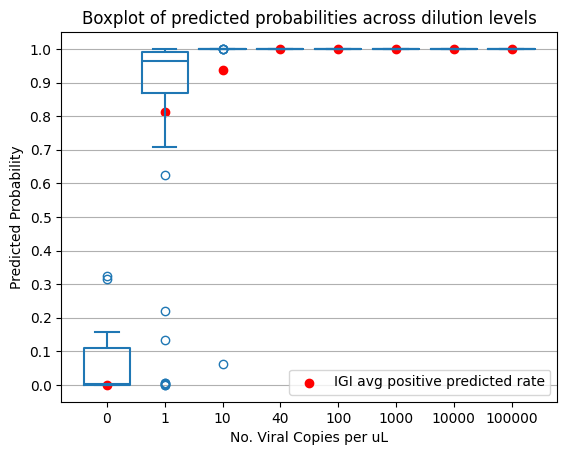

In [10]:
# boxplot_df = pd.concat([known_pred_df[['dilution_level','outputs']], water_output_df[['dilution_level','outputs']]], axis=0)
boxplot_df = pd.concat([boxplot_known_df[['well_position','dilution_level','outputs','pred','new_igi_call']], 
                        water_output_df[['well_position','dilution_level','outputs','pred','new_igi_call']]], axis=0)

sns.boxplot(data=boxplot_df, x='dilution_level', y = 'outputs', fill = False)
plt.scatter(0, water_output_df.groupby('curve_idx').new_igi_call.mean().mean(), color = 'red', label = 'IGI avg positive predicted rate')
plt.scatter(1, boxplot_known_df[boxplot_known_df.dilution_level == 1].new_igi_call.mean(), color = 'red')
plt.scatter(2, boxplot_known_df[boxplot_known_df.dilution_level == 10].new_igi_call.mean(), color = 'red')
plt.scatter(3, boxplot_known_df[boxplot_known_df.dilution_level == 40].new_igi_call.mean(), color = 'red')
plt.scatter(4, boxplot_known_df[boxplot_known_df.dilution_level == 100].new_igi_call.mean(), color = 'red')
plt.scatter(5, boxplot_known_df[boxplot_known_df.dilution_level == 1000].new_igi_call.mean(), color = 'red')
plt.scatter(6, boxplot_known_df[boxplot_known_df.dilution_level == 10000].new_igi_call.mean(), color = 'red')
plt.scatter(7, boxplot_known_df[boxplot_known_df.dilution_level == 100000].new_igi_call.mean(), color = 'red')

plt.title('Boxplot of predicted probabilities across dilution levels')
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

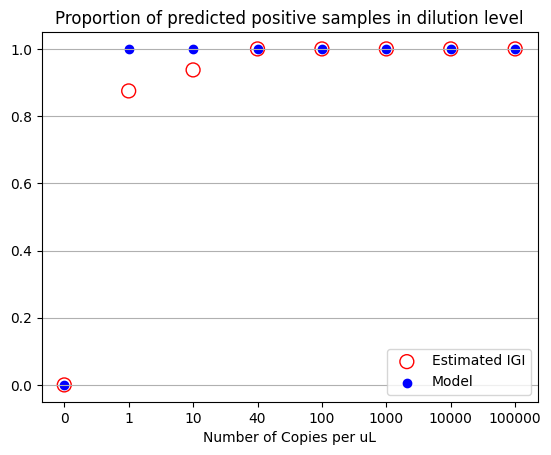

In [11]:

known_sampled_pred = (boxplot_df
                      .groupby(['dilution_level', 'well_position'])
                      .agg(sample_pred = ('pred', 'mean'),
                           sample_igi_call = ('new_igi_call', 'mean')).reset_index())
known_sampled_pred['sample_pred'] = 1*(known_sampled_pred.sample_pred >= 0.5)
known_sampled_pred['sample_igi_call'] = 1*(known_sampled_pred.sample_igi_call >= 0.5)

pos_known_pred = known_sampled_pred.groupby('dilution_level')[['sample_igi_call','sample_pred']].apply(lambda x: x.sum()/len(x)).reset_index()
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')

plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_igi_call', facecolor='none', edgecolors='red', s = 100)
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_pred', color = 'blue')
plt.legend(labels=['Estimated IGI', 'Model'])
plt.title('Proportion of predicted positive samples in dilution level')
plt.xlabel('Number of Copies per uL')
plt.grid(axis='y')
plt.show()

In [12]:
boxplot_df['groundtruth_label'] = 1*(boxplot_df.dilution_level != 0)
known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.outputs)
print('Model AUC on known:', known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.pred)

Model AUC on known: 0.9820833333333332


,acc,f1,tn,fp,fn,tp
0,0.963134,0.978723,25,0,8,184


In [13]:

igi_known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)
print('IGI AUC on known:', igi_known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)

IGI AUC on known: 0.9713541666666667


,acc,f1,tn,fp,fn,tp
0,0.949309,0.970509,25,0,11,181


### chip60

In [14]:
chip60_pred_df = (chip60_pred
                  .merge(chip60_df, on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

chip60_boxplot = (chip60_pred_df[['curve_idx','dilution','groundtruth_label','outputs']]
                  .merge(chip60_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .melt(id_vars=['curve_idx','dilution','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
chip60_boxplot['model'] = chip60_boxplot.model.replace({'outputs':'model',
                                                        'prob':'qpcR'})

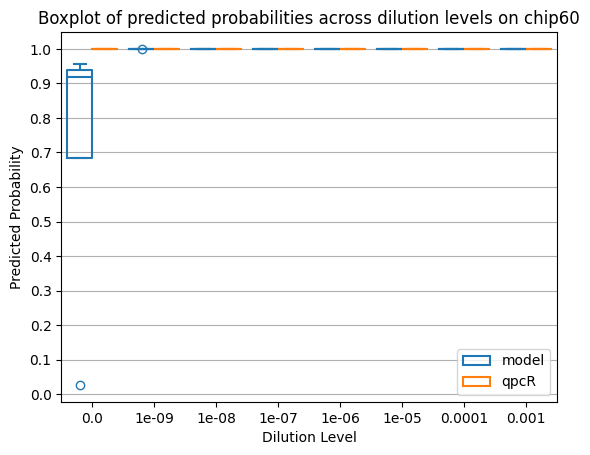

In [15]:


sns.boxplot(data=chip60_boxplot, x='dilution', y = 'predicted_score', hue='model', fill = False)

plt.title('Boxplot of predicted probabilities across dilution levels on chip60')
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('Dilution Level')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

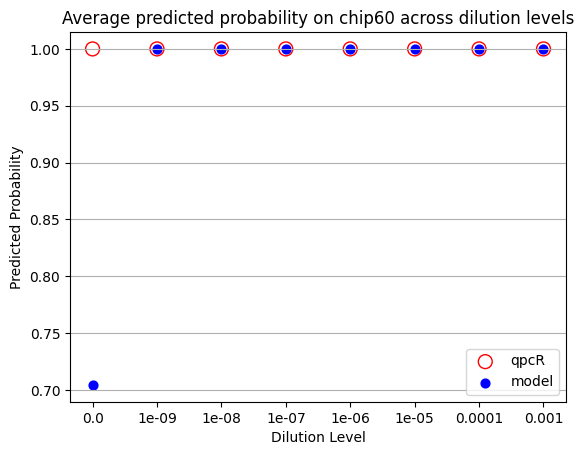

In [16]:
chip60_avg_pred_score = chip60_boxplot.groupby(['dilution','model']).predicted_score.mean().reset_index()
chip60_avg_pred_score['dilution'] = chip60_avg_pred_score.dilution.astype('str')
plt.scatter(data=chip60_avg_pred_score[chip60_avg_pred_score.model=='qpcR'],
             x='dilution', y='predicted_score', facecolor='none', edgecolors='red', s = 100)
plt.scatter(data=chip60_avg_pred_score[chip60_avg_pred_score.model=='model'],
             x='dilution', y='predicted_score', color='blue', s = 40)

plt.title('Average predicted probability on chip60 across dilution levels')
# plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('Dilution Level')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend(labels=['qpcR','model'])

In [17]:

model_chip_auc = roc_auc_score(chip60_boxplot[chip60_boxplot.model == 'model'].groundtruth_label, 
                             chip60_boxplot[chip60_boxplot.model == 'model'].predicted_score)
print('Model AUC on known:', model_chip_auc)
chip60_boxplot['model_pred'] = 1*(chip60_boxplot.predicted_score >= 0.5)
calc_metrics(chip60_boxplot[chip60_boxplot.model == 'model'].groundtruth_label, 
             chip60_boxplot[chip60_boxplot.model == 'model'].model_pred)

Model AUC on known: 1.0


,acc,f1,tn,fp,fn,tp
0,0.90625,0.949153,1,3,0,28


In [18]:

qpcr_chip_auc = roc_auc_score(chip60_boxplot[chip60_boxplot.model == 'qpcR'].groundtruth_label, 
                             chip60_boxplot[chip60_boxplot.model == 'qpcR'].predicted_score)
print('qpcR AUC on known:', qpcr_chip_auc)
chip60_boxplot['qpcr_pred'] = 1*(chip60_boxplot.predicted_score >= 0.5)
calc_metrics(chip60_boxplot[chip60_boxplot.model == 'qpcR'].groundtruth_label, 
             chip60_boxplot[chip60_boxplot.model == 'qpcR'].qpcr_pred)

qpcR AUC on known: 0.5


,acc,f1,tn,fp,fn,tp
0,0.875,0.933333,0,4,0,28


### karlen

In [19]:
karlen_pred_df = (karlen_pred
                  .merge(karlen_df, on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

karlen_boxplot = (karlen_pred_df[['curve_idx','dilution_fold','groundtruth_label','outputs']]
                  .merge(karlen_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .melt(id_vars=['curve_idx','dilution_fold','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
karlen_boxplot['model'] = karlen_boxplot.model.replace({'outputs':'model',
                                                        'prob':'qpcR'})

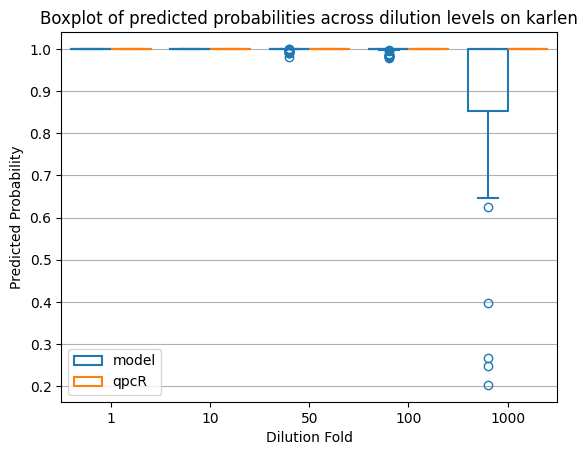

In [20]:


sns.boxplot(data=karlen_boxplot, x='dilution_fold', y = 'predicted_score', hue='model', fill = False)

plt.title('Boxplot of predicted probabilities across dilution levels on karlen')
# plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('Dilution Fold')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

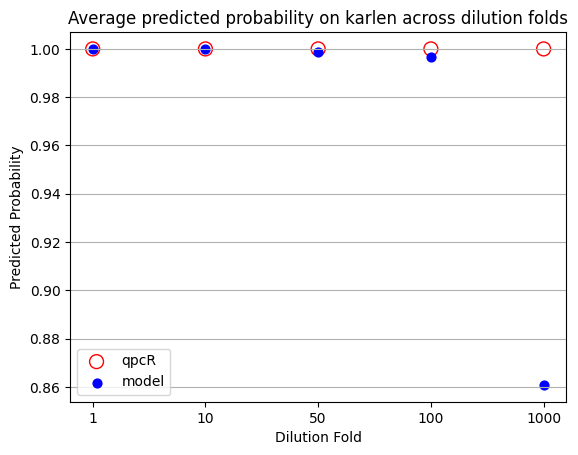

In [21]:
karlen_avg_pred_score = karlen_boxplot.groupby(['dilution_fold','model']).predicted_score.mean().reset_index()
karlen_avg_pred_score['dilution_fold'] = karlen_avg_pred_score.dilution_fold.astype('str')
plt.scatter(data=karlen_avg_pred_score[karlen_avg_pred_score.model=='qpcR'],
             x='dilution_fold', y='predicted_score', facecolor='none', edgecolors='red', s = 100)
plt.scatter(data=karlen_avg_pred_score[karlen_avg_pred_score.model=='model'],
             x='dilution_fold', y='predicted_score', color='blue', s = 40)

plt.title('Average predicted probability on karlen across dilution folds')
# plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('Dilution Fold')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend(labels=['qpcR','model'])